In [1]:
# =========================
# PHASE 2 — SETUP
# =========================

import os
import numpy as np
import torch
import random

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "sar_data"

print("Device:", device)
print("Setup ready ✅")

Device: cuda
Setup ready ✅


In [4]:
# =========================
# STEP 2A: FIND DATA PATH
# =========================

import os

print("Current working directory:\n")
print(os.getcwd())

print("\nFiles and folders here:\n")
print(os.listdir("."))

print("\n--- Checking subfolders ---\n")

for item in os.listdir("."):
    if os.path.isdir(item):
        print(f"\n📁 {item} contains:")
        try:
            print(os.listdir(item))
        except:
            print("Cannot access")

Current working directory:

C:\Users\Bramha\Desktop\inSAR\sar_data

Files and folders here:

['.ipynb_checkpoints', 'image_00.tif', 'image_01.tif', 'image_02.tif', 'image_03.tif', 'image_04.tif', 'image_05.tif', 'image_06.tif', 'image_07.tif', 'image_08.tif', 'image_09.tif', 'image_10.tif', 'image_11.tif', 'image_12.tif', 'image_13.tif', 'image_14.tif', 'image_15.tif', 'image_16.tif', 'image_17.tif', 'image_18.tif', 'image_19.tif', 'phase2_contrastive.ipynb.ipynb']

--- Checking subfolders ---


📁 .ipynb_checkpoints contains:
['phase2_contrastive.ipynb-checkpoint.ipynb']


In [5]:
# =========================
# STEP 2: LOAD LOCAL IMAGES (FINAL)
# =========================

import os
import rasterio
import numpy as np
import cv2

DATA_DIR = "."   # 🔥 already inside sar_data
TARGET_SIZE = 2048

image_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".tif")])

images = []

print("Loading images...\n")

for idx, file in enumerate(image_files):
    path = os.path.join(DATA_DIR, file)
    
    try:
        with rasterio.open(path) as src:
            img = src.read(1)
        
        img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
        
        images.append(img)
        print(f"[{idx+1}] Loaded")

    except Exception as e:
        print(f"[{idx+1}] Skipped ❌")

print("\nDone ✅")
print("Total images:", len(images))

Loading images...

[1] Loaded
[2] Loaded
[3] Skipped ❌
[4] Loaded
[5] Skipped ❌
[6] Loaded
[7] Loaded
[8] Loaded
[9] Loaded
[10] Loaded
[11] Loaded
[12] Loaded
[13] Loaded
[14] Loaded
[15] Skipped ❌
[16] Loaded
[17] Loaded
[18] Loaded
[19] Loaded
[20] Loaded

Done ✅
Total images: 17


In [6]:
# =========================
# STEP 3: BUILD TEMPORAL PATCH INDEX
# =========================

PATCH_SIZE = 256
STRIDE = 256

from collections import defaultdict

# key = (i, j) → value = list of patches across time
patch_dict = defaultdict(list)

print("Building temporal patch index...\n")

for t, img in enumerate(images):
    
    h, w = img.shape
    
    for i in range(0, h - PATCH_SIZE, STRIDE):
        for j in range(0, w - PATCH_SIZE, STRIDE):
            
            patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            
            # store with time info
            patch_dict[(i, j)].append((t, patch))

print("Done ✅")
print("Total spatial locations:", len(patch_dict))

# check one example
sample_key = list(patch_dict.keys())[0]
print("\nSample location:", sample_key)
print("Number of timestamps at this location:", len(patch_dict[sample_key]))

Building temporal patch index...

Done ✅
Total spatial locations: 49

Sample location: (0, 0)
Number of timestamps at this location: 17


In [7]:
# =========================
# STEP 4: CREATE CONTRASTIVE PAIRS
# =========================

import random

positive_pairs = []
negative_pairs = []

print("Creating contrastive pairs...\n")

positions = list(patch_dict.keys())

for pos in positions:
    patches = patch_dict[pos]
    
    # sort by time
    patches = sorted(patches, key=lambda x: x[0])
    
    # create positive pairs (consecutive timestamps)
    for i in range(len(patches) - 1):
        p1 = patches[i][1]
        p2 = patches[i+1][1]
        
        positive_pairs.append((p1, p2))

# create negative pairs
for _ in range(len(positive_pairs)):
    pos1, pos2 = random.sample(positions, 2)
    
    p1 = random.choice(patch_dict[pos1])[1]
    p2 = random.choice(patch_dict[pos2])[1]
    
    negative_pairs.append((p1, p2))

print("Done ✅")
print("Positive pairs:", len(positive_pairs))
print("Negative pairs:", len(negative_pairs))

Creating contrastive pairs...

Done ✅
Positive pairs: 784
Negative pairs: 784


In [8]:
# =========================
# STEP 5: PREPROCESS + BUILD DATASET
# =========================

import numpy as np
import torch

def preprocess(patch):
    patch = patch.astype(np.float32)
    
    # dB scale
    patch = 10 * np.log10(patch + 1e-10)
    
    # normalize
    patch = (patch - patch.mean()) / (patch.std() + 1e-6)
    
    return patch

X1 = []
X2 = []
Y  = []

print("Preparing dataset...\n")

# positive pairs
for p1, p2 in positive_pairs:
    X1.append(preprocess(p1))
    X2.append(preprocess(p2))
    Y.append(1)

# negative pairs
for p1, p2 in negative_pairs:
    X1.append(preprocess(p1))
    X2.append(preprocess(p2))
    Y.append(0)

# convert to tensors
X1 = torch.tensor(np.array(X1)).unsqueeze(1)
X2 = torch.tensor(np.array(X2)).unsqueeze(1)
Y  = torch.tensor(Y).float()

print("Done ✅")
print("X1:", X1.shape)
print("X2:", X2.shape)
print("Y :", Y.shape)

Preparing dataset...

Done ✅
X1: torch.Size([1568, 1, 256, 256])
X2: torch.Size([1568, 1, 256, 256])
Y : torch.Size([1568])


In [9]:
# =========================
# STEP 6: SIAMESE NETWORK
# =========================

import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 256),
            nn.ReLU(),
        )
    
    def forward(self, x):
        return self.net(x)

class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
    
    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        return f1, f2

model = SiameseNet().to(device)

print("Model ready ✅")

Model ready ✅


In [10]:
# =========================
# STEP 7: CONTRASTIVE LOSS
# =========================

import torch.nn.functional as F

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super().__init__()
        self.margin = margin
    
    def forward(self, f1, f2, label):
        # Euclidean distance
        dist = F.pairwise_distance(f1, f2)
        
        # contrastive loss
        loss = torch.mean(
            label * dist**2 +
            (1 - label) * torch.clamp(self.margin - dist, min=0.0)**2
        )
        
        return loss

criterion = ContrastiveLoss(margin=2.0)

print("Contrastive loss ready ✅")

Contrastive loss ready ✅


In [11]:
# =========================
# STEP 8: TRAIN SIAMESE MODEL
# =========================

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# dataset
dataset = TensorDataset(X1, X2, Y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

print("Starting contrastive training...\n")

for epoch in range(EPOCHS):
    total_loss = 0
    
    for x1, x2, y in dataloader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y  = y.to(device)
        
        f1, f2 = model(x1, x2)
        
        loss = criterion(f1, f2, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss:.4f}")

# save model
torch.save(model.state_dict(), "siamese_model.pth")

print("\nTraining complete ✅")

Starting contrastive training...

Epoch 1/10 Loss: 1.7696
Epoch 2/10 Loss: 0.6318
Epoch 3/10 Loss: 0.5105
Epoch 4/10 Loss: 0.4611
Epoch 5/10 Loss: 0.4212
Epoch 6/10 Loss: 0.4106
Epoch 7/10 Loss: 0.3953
Epoch 8/10 Loss: 0.3883
Epoch 9/10 Loss: 0.4011
Epoch 10/10 Loss: 0.3911

Training complete ✅


In [12]:
# =========================
# STEP 8: TRAIN SIAMESE MODEL
# =========================

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# dataset
dataset = TensorDataset(X1, X2, Y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

model = SiameseNet().to(device)

# optimizer
optimizer = optim.Adam(model.parameters(), lr=5e-4)

EPOCHS = 20

print("Starting contrastive training...\n")

for epoch in range(EPOCHS):
    total_loss = 0
    
    for x1, x2, y in dataloader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y  = y.to(device)
        
        f1, f2 = model(x1, x2)
        
        loss = criterion(f1, f2, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss:.4f}")

# save model
torch.save(model.state_dict(), "siamese_model_tuning.pth")

print("\nTraining complete ✅")

Starting contrastive training...

Epoch 1/20 Loss: 1.7833
Epoch 2/20 Loss: 0.5815
Epoch 3/20 Loss: 0.4676
Epoch 4/20 Loss: 0.4112
Epoch 5/20 Loss: 0.4076
Epoch 6/20 Loss: 0.3841
Epoch 7/20 Loss: 0.3834
Epoch 8/20 Loss: 0.3715
Epoch 9/20 Loss: 0.3720
Epoch 10/20 Loss: 0.3670
Epoch 11/20 Loss: 0.3715
Epoch 12/20 Loss: 0.3625
Epoch 13/20 Loss: 0.3633
Epoch 14/20 Loss: 0.3621
Epoch 15/20 Loss: 0.3577
Epoch 16/20 Loss: 0.3536
Epoch 17/20 Loss: 0.3526
Epoch 18/20 Loss: 0.3512
Epoch 19/20 Loss: 0.3617
Epoch 20/20 Loss: 0.3554

Training complete ✅


In [13]:
# =========================
# STEP 9: FEATURE EXTRACTION (PHASE 2)
# =========================

import torch

# load tuned model
model = SiameseNet().to(device)
model.load_state_dict(torch.load("siamese_model_tuning.pth"))
model.eval()

features = []

print("Extracting features (Phase 2)...\n")

with torch.no_grad():
    for img in images:
        
        h, w = img.shape
        
        for i in range(0, h - 256, 256):
            for j in range(0, w - 256, 256):
                
                patch = img[i:i+256, j:j+256]
                
                # preprocess (same as before)
                patch = patch.astype(np.float32)
                patch = 10 * np.log10(patch + 1e-10)
                patch = (patch - patch.mean()) / (patch.std() + 1e-6)
                
                patch = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)
                
                feat = model.encoder(patch)
                features.append(feat.cpu())

features = torch.cat(features)

print("Done ✅")
print("Feature shape:", features.shape)

C:\Users\Bramha\AppData\Local\Temp\ipykernel_13532\2965521959.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("siamese_model_tuning.pth"

Extracting features (Phase 2)...

Done ✅
Feature shape: torch.Size([833, 256])


In [14]:
# =========================
# STEP 10: TEMPORAL CHANGE (PHASE 2)
# =========================

import numpy as np
from collections import defaultdict

features_np = features.numpy()

print("Computing temporal changes (Phase 2)...\n")

# rebuild mapping
idx = 0
position_dict = defaultdict(list)

for t in range(len(images)):
    for i in range(0, 2048 - 256, 256):
        for j in range(0, 2048 - 256, 256):
            position_dict[(i, j)].append(idx)
            idx += 1

change_scores = []

for pos, indices in position_dict.items():
    
    seq = features_np[indices]
    
    # differences over time
    diffs = np.linalg.norm(seq[1:] - seq[:-1], axis=1)
    
    score = diffs.mean()
    
    change_scores.append((pos, score))

print("Done ✅")
print("Total spatial locations:", len(change_scores))

Computing temporal changes (Phase 2)...

Done ✅
Total spatial locations: 49


Change map shape: (7, 7)


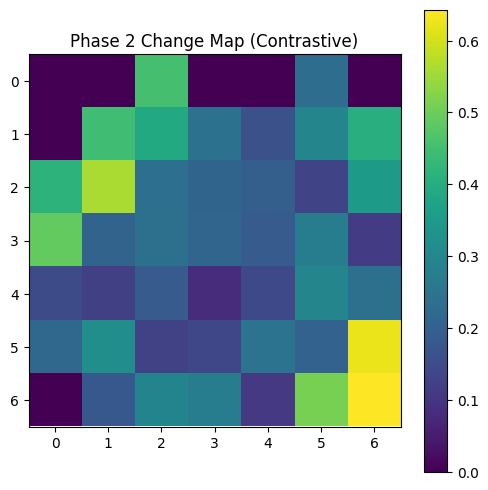

In [15]:
# =========================
# STEP 11: CHANGE MAP (PHASE 2)
# =========================

import numpy as np
import matplotlib.pyplot as plt

grid_size = int(np.sqrt(len(change_scores)))  # should be 7

change_map = np.zeros((grid_size, grid_size))

for (i, j), score in change_scores:
    x = i // 256
    y = j // 256
    change_map[x, y] = score

print("Change map shape:", change_map.shape)

# visualize
plt.figure(figsize=(6,6))
plt.imshow(change_map)
plt.colorbar()
plt.title("Phase 2 Change Map (Contrastive)")
plt.show()

In [16]:
# =========================
# STEP 12: TOP CHANGES (PHASE 2)
# =========================

sorted_changes = sorted(change_scores, key=lambda x: x[1], reverse=True)

TOP_K = 5

print("Top changing regions (Phase 2):\n")

for i in range(TOP_K):
    (pos, score) = sorted_changes[i]
    
    x = pos[0] // 256
    y = pos[1] // 256
    
    print(f"Rank {i+1}: Grid ({x}, {y}) | Score: {score:.4f}")

Top changing regions (Phase 2):

Rank 1: Grid (6, 6) | Score: 0.6434
Rank 2: Grid (5, 6) | Score: 0.6240
Rank 3: Grid (2, 1) | Score: 0.5621
Rank 4: Grid (6, 5) | Score: 0.5104
Rank 5: Grid (3, 0) | Score: 0.4877


In [21]:
# =========================
# DEBUG: CHECK IMAGE STATS
# =========================

import numpy as np

img = images[0]

print("RAW IMAGE STATS:")
print("Min:", np.min(img))
print("Max:", np.max(img))
print("Mean:", np.mean(img))
print("Std:", np.std(img))

img_db = 10 * np.log10(img + 1e-10)

print("\nDB IMAGE STATS:")
print("Min:", np.min(img_db))
print("Max:", np.max(img_db))
print("Mean:", np.mean(img_db))
print("Std:", np.std(img_db))

RAW IMAGE STATS:
Min: 0
Max: 58439
Mean: 464.94400358200073
Std: 741.8876364711329

DB IMAGE STATS:
Min: -100.0
Max: 47.6670277573937
Mean: -58.40640339610394
Std: 61.13836679029153


In [22]:
# pick image with highest contrast
best_img = None
best_std = 0

for im in images:
    im_db = 10 * np.log10(im + 1e-10)
    std = np.std(im_db)
    
    if std > best_std:
        best_std = std
        best_img = im

img = best_img

print("Selected image std:", best_std)

Selected image std: 62.22836359601473


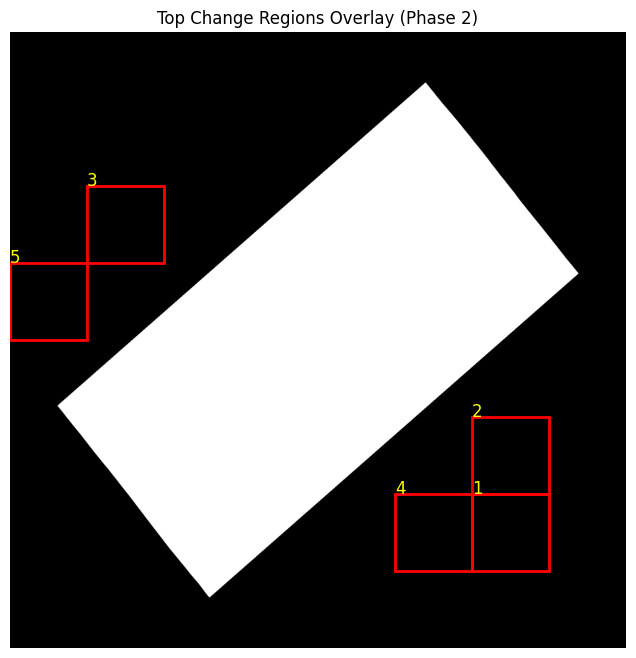

In [20]:
# =========================
# STEP 13: OVERLAY TOP CHANGES (REAL)
# =========================

import matplotlib.pyplot as plt
import matplotlib.patches as patches

TOP_K = 5

# sort changes
sorted_changes = sorted(change_scores, key=lambda x: x[1], reverse=True)

# use first image as reference
img = images[0]

fig, ax = plt.subplots(1, figsize=(8, 8))

# dB conversion
img_db = 10 * np.log10(img + 1e-10)

# ✅ strong clipping (very important)
img_db = np.clip(img_db, -25, 5)

# ✅ normalize to 0–1
img_norm = (img_db + 25) / 30.0

ax.imshow(img_norm, cmap='gray')

for i in range(TOP_K):
    (pos, score) = sorted_changes[i]
    
    x, y = pos  # exact pixel position
    
    rect = patches.Rectangle(
        (y, x), 256, 256,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    
    ax.add_patch(rect)
    ax.text(y, x, f"{i+1}", color='yellow', fontsize=12)

plt.title("Top Change Regions Overlay (Phase 2)")
plt.axis('off')
plt.show()

Using image with std: 62.22836359601473


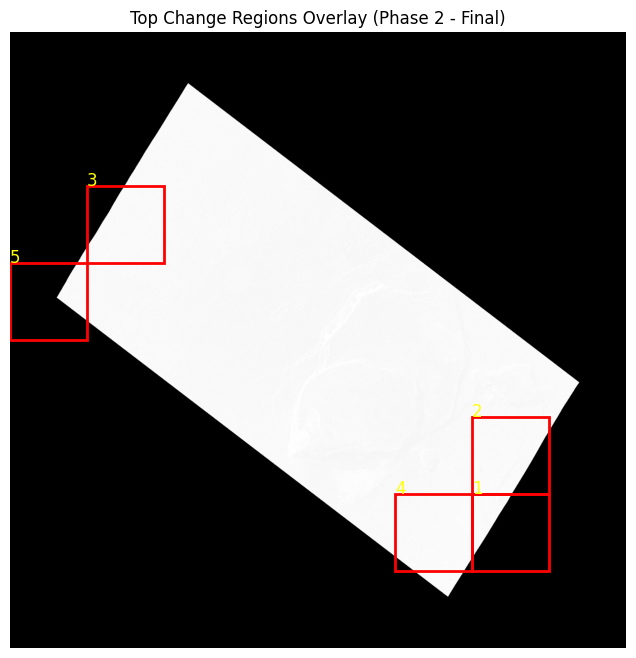

In [23]:
# =========================
# STEP 13: OVERLAY TOP CHANGES (FINAL FIXED)
# =========================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

TOP_K = 5

# =========================
# 1. SORT TOP CHANGES
# =========================
sorted_changes = sorted(change_scores, key=lambda x: x[1], reverse=True)

# =========================
# 2. SELECT BEST IMAGE (MAX CONTRAST)
# =========================
best_img = None
best_std = 0

for im in images:
    im_db = 10 * np.log10(im + 1e-10)
    std = np.std(im_db)
    
    if std > best_std:
        best_std = std
        best_img = im

img = best_img
print("Using image with std:", best_std)

# =========================
# 3. PROPER SAR VISUALIZATION
# =========================

# dB conversion
img_db = 10 * np.log10(img + 1e-10)

# ✅ adaptive percentile clipping (KEY FIX)
low = np.percentile(img_db, 30)
high = np.percentile(img_db, 99.5)

img_clipped = np.clip(img_db, low, high)

# normalize to 0–1
img_norm = (img_clipped - low) / (high - low + 1e-8)

# =========================
# 4. PLOT
# =========================
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img_norm, cmap='gray')

# =========================
# 5. DRAW TOP REGIONS
# =========================
for i in range(TOP_K):
    (pos, score) = sorted_changes[i]
    
    x, y = pos
    
    rect = patches.Rectangle(
        (y, x), 256, 256,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    
    ax.add_patch(rect)
    ax.text(y, x, f"{i+1}", color='yellow', fontsize=12)

plt.title("Top Change Regions Overlay (Phase 2 - Final)")
plt.axis('off')
plt.show()

In [24]:
# =========================
# STEP 14: TEMPORAL EVOLUTION (TOP REGION)
# =========================

import numpy as np

# get top region (rank 1)
top_region = sorted(change_scores, key=lambda x: x[1], reverse=True)[0][0]

x, y = top_region

print("Top region (pixel coords):", (x, y))

patch_sequence = []

for idx, img in enumerate(images):
    patch = img[x:x+256, y:y+256]
    patch_sequence.append(patch)

print("Total timestamps:", len(patch_sequence))

Top region (pixel coords): (1536, 1536)
Total timestamps: 17


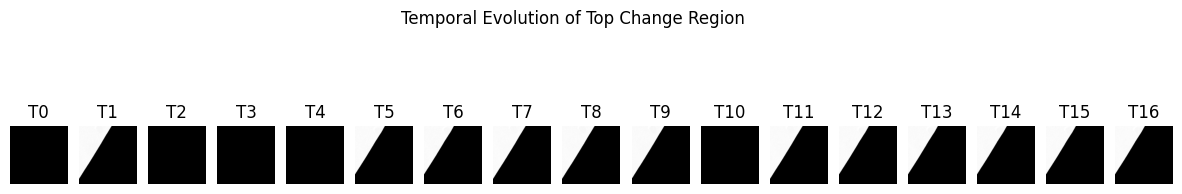

In [25]:
# =========================
# VISUALIZE TEMPORAL EVOLUTION (FIXED)
# =========================

import matplotlib.pyplot as plt

num = len(patch_sequence)

plt.figure(figsize=(15, 3))

for i in range(num):
    patch = patch_sequence[i]
    
    # ✅ SAME FIX: proper SAR visualization
    patch_db = 10 * np.log10(patch + 1e-10)
    
    low = np.percentile(patch_db, 20)
    high = np.percentile(patch_db, 99)
    
    patch_db = np.clip(patch_db, low, high)
    patch_norm = (patch_db - low) / (high - low + 1e-8)
    
    plt.subplot(1, num, i+1)
    plt.imshow(patch_norm, cmap='gray')
    plt.title(f"T{i}")
    plt.axis('off')

plt.suptitle("Temporal Evolution of Top Change Region")
plt.show()

Selecting STRONG + CONSISTENT region...

Consistent regions: 20
Selected region: (1280, 1536)
Valid timestamps used: [1, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16]


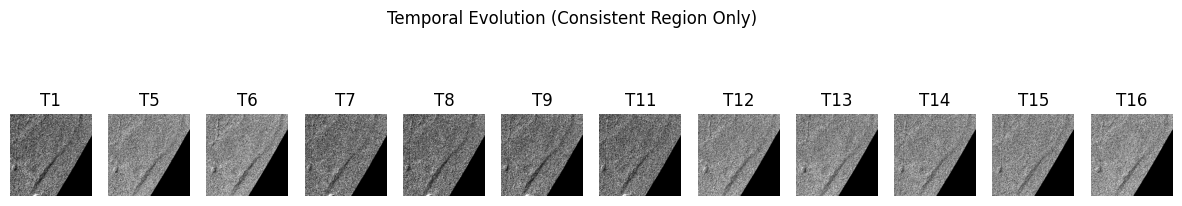

In [28]:
# =========================
# STEP 14 (FINAL+++): CLEAN TEMPORAL EVOLUTION
# =========================

import numpy as np
import matplotlib.pyplot as plt

print("Selecting STRONG + CONSISTENT region...\n")

valid_changes = []

for (pos, score) in change_scores:
    x, y = pos
    
    valid_count = 0
    
    # check consistency across time
    for img in images:
        patch = img[x:x+256, y:y+256]
        patch_db = 10 * np.log10(patch + 1e-10)
        
        valid_pixels = np.sum(patch_db > -40)
        ratio = valid_pixels / patch_db.size
        
        if ratio > 0.6:
            valid_count += 1
    
    # require consistency across time
    if valid_count >= len(images) * 0.6:  # 🔥 KEY CONDITION
        valid_changes.append((pos, score, valid_count))

# sort
valid_changes = sorted(valid_changes, key=lambda x: x[1], reverse=True)

print("Consistent regions:", len(valid_changes))

# pick best
top_region = valid_changes[0][0]
x, y = top_region

print("Selected region:", (x, y))

# =========================
# EXTRACT VALID PATCHES ONLY
# =========================

patch_sequence = []
valid_indices = []

for idx, img in enumerate(images):
    patch = img[x:x+256, y:y+256]
    patch_db = 10 * np.log10(patch + 1e-10)
    
    valid_pixels = np.sum(patch_db > -40)
    ratio = valid_pixels / patch_db.size
    
    if ratio > 0.6:
        patch_sequence.append(patch)
        valid_indices.append(idx)

print("Valid timestamps used:", valid_indices)

# =========================
# VISUALIZE CLEAN SEQUENCE
# =========================

plt.figure(figsize=(15, 3))

for i, patch in enumerate(patch_sequence):
    
    patch_db = 10 * np.log10(patch + 1e-10)
    
    low = np.percentile(patch_db, 20)
    high = np.percentile(patch_db, 99)
    
    patch_db = np.clip(patch_db, low, high)
    patch_norm = (patch_db - low) / (high - low + 1e-8)
    
    plt.subplot(1, len(patch_sequence), i+1)
    plt.imshow(patch_norm, cmap='gray')
    plt.title(f"T{valid_indices[i]}")
    plt.axis('off')

plt.suptitle("Temporal Evolution (Consistent Region Only)")
plt.show()

In [29]:
# =========================
# STEP 15: FIND MOST DYNAMIC REGION
# =========================

import numpy as np

print("Searching for most dynamic region...\n")

dynamic_scores = []

for (pos, _) in change_scores:
    x, y = pos
    
    patches = []
    
    for img in images:
        patch = img[x:x+256, y:y+256]
        
        # convert to dB
        patch_db = 10 * np.log10(patch + 1e-10)
        
        patches.append(patch_db)
    
    patches = np.array(patches)  # shape: [T, H, W]
    
    # compute temporal variance
    temporal_var = np.var(patches, axis=0)
    
    # average variance of region
    score = np.mean(temporal_var)
    
    dynamic_scores.append((pos, score))

# sort by highest variation
dynamic_scores = sorted(dynamic_scores, key=lambda x: x[1], reverse=True)

print("Top dynamic regions computed ✅")

# pick best
top_dynamic_region = dynamic_scores[0][0]

print("Most dynamic region:", top_dynamic_region)

Searching for most dynamic region...

Top dynamic regions computed ✅
Most dynamic region: (256, 512)


Valid timestamps: [1, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16]


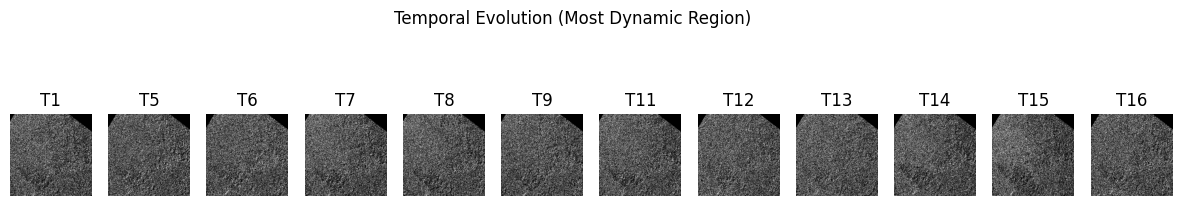

In [30]:
# =========================
# STEP 16: VISUALIZE DYNAMIC REGION
# =========================

import matplotlib.pyplot as plt

x, y = top_dynamic_region

patch_sequence = []

valid_indices = []

for idx, img in enumerate(images):
    patch = img[x:x+256, y:y+256]
    
    patch_db = 10 * np.log10(patch + 1e-10)
    
    # filter empty frames
    valid_pixels = np.sum(patch_db > -40)
    ratio = valid_pixels / patch_db.size
    
    if ratio > 0.6:
        patch_sequence.append(patch)
        valid_indices.append(idx)

print("Valid timestamps:", valid_indices)

# visualize
plt.figure(figsize=(15, 3))

for i, patch in enumerate(patch_sequence):
    
    patch_db = 10 * np.log10(patch + 1e-10)
    
    low = np.percentile(patch_db, 20)
    high = np.percentile(patch_db, 99)
    
    patch_db = np.clip(patch_db, low, high)
    patch_norm = (patch_db - low) / (high - low + 1e-8)
    
    plt.subplot(1, len(patch_sequence), i+1)
    plt.imshow(patch_norm, cmap='gray')
    plt.title(f"T{valid_indices[i]}")
    plt.axis('off')

plt.suptitle("Temporal Evolution (Most Dynamic Region)")
plt.show()

In [31]:
# =========================
# STEP 17: CHANGE TYPE CLUSTERING
# =========================

from sklearn.cluster import KMeans
import numpy as np

print("Clustering temporal behavior...\n")

# reshape features per spatial location
# features shape = [833, 256]
# 49 locations × 17 timestamps

num_locations = 49
num_times = len(images)

features_reshaped = features.view(num_locations, num_times, -1)

# compute temporal variance per location
temporal_variance = []

for i in range(num_locations):
    loc_features = features_reshaped[i]  # [T, F]
    
    var = torch.var(loc_features, dim=0).mean().item()
    
    temporal_variance.append(var)

temporal_variance = np.array(temporal_variance).reshape(-1, 1)

# cluster into 3 types
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(temporal_variance)

print("Clustering complete ✅")

Clustering temporal behavior...

Clustering complete ✅


C:\Users\Bramha\anaconda3\envs\torch\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


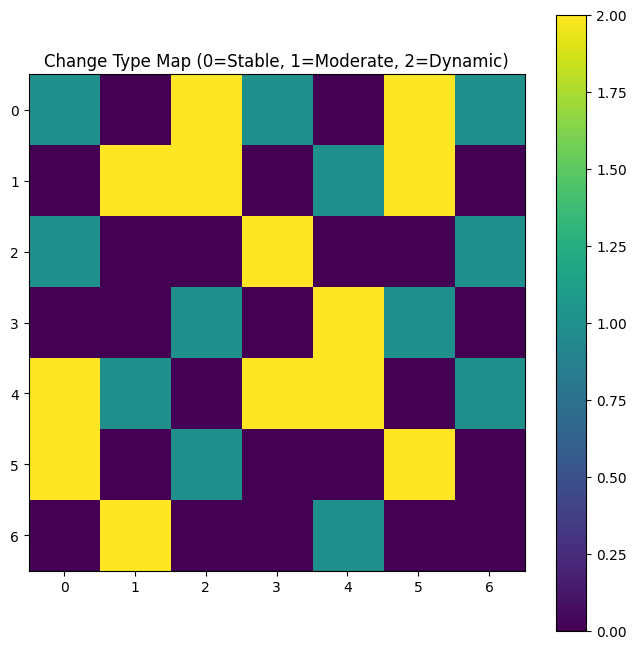

In [33]:
# =========================
# STEP 18: VISUALIZE CHANGE TYPES
# =========================

import matplotlib.pyplot as plt

grid_size = int(np.sqrt(num_locations))
change_map = labels.reshape(grid_size, grid_size)

plt.figure(figsize=(8, 8))
plt.imshow(change_map, cmap='viridis')
plt.colorbar()
plt.title("Change Type Map (0=Stable, 1=Moderate, 2=Dynamic)")
plt.show()

In [35]:
# =========================
# STEP 20: ANOMALY DETECTION
# =========================

from sklearn.ensemble import IsolationForest
import numpy as np

print("Detecting anomalies...\n")

# use temporal variance (same as clustering step)
X = temporal_variance  # shape: [49, 1]

# train model
iso = IsolationForest(contamination=0.2, random_state=42)
anomaly_labels = iso.fit_predict(X)

# convert:
# -1 = anomaly, 1 = normal
anomaly_map = anomaly_labels.reshape(7, 7)

print("Anomaly detection complete ✅")

Detecting anomalies...

Anomaly detection complete ✅


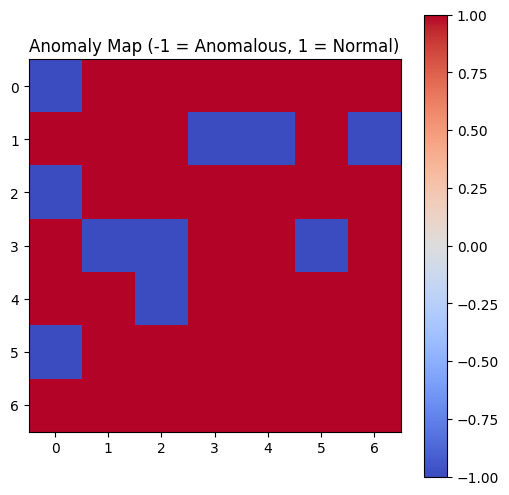

In [36]:
# =========================
# STEP 21: VISUALIZE ANOMALIES
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(anomaly_map, cmap='coolwarm')
plt.colorbar()
plt.title("Anomaly Map (-1 = Anomalous, 1 = Normal)")

plt.show()

In [37]:
print("Anomalies count:", np.sum(anomaly_labels == -1))

Anomalies count: 10
